<a href="https://colab.research.google.com/github/AishwaryaKalloli/andrejk/blob/main/makemore3_deepdive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import random
random.seed(27)
g = torch.Generator().manual_seed(2147483647)

# Get data

In [ ]:
!wget -q https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
len(words), words[:3]

(32033, ['emma', 'olivia', 'ava'])

# Extract features

In [ ]:
DOT = '.'
chars = [DOT] + sorted(list(set(''.join(words))))

In [ ]:
stoi = {char: i for i, char in enumerate(chars)}
itos = {i : char for i, char in enumerate(chars)}
vocab_size = len(itos.items())

In [ ]:
def sprint(**kwargs):
    for name, var in kwargs.items():
        print(f'{name}: {var}')

In [ ]:
sprint(vocab_size=vocab_size, stoi=stoi, itos=itos)

vocab_size: 27
stoi: {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
itos: {0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


# Dataset builder (X, Y)

In [ ]:
def build_dataset(words, context_window_len):
    X, Y = [], []
    for word in words:
        context = [0] * context_window_len
        for char in word + DOT:
            X.append(context.copy())
            Y.append(stoi[char])
            context = context[1:] + [stoi[char]]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y


# Create dataset (train, test, validation)

In [ ]:
random.shuffle(words)

context_window_len = 3
edge1 = int(0.8 * len(words))
edge2 = int(0.9 * len(words))

Xtrain, Ytrain = build_dataset(words[:edge1], context_window_len)
Xtest, Ytest = build_dataset(words[edge1:edge2], context_window_len)
Xval, Yval = build_dataset(words[edge2:], context_window_len)
sprint(Xtrain_shape=Xtrain.shape, Ytrain_shape=Ytrain.shape)

Xtrain_shape: torch.Size([182497, 3])
Ytrain_shape: torch.Size([182497])


# Create embeddings

In [ ]:
embedding_dimensions = 10

# takes a letter and creates an n dimensional representation for it, initialised randomly learned by the network
C = torch.randn((vocab_size, embedding_dimensions), generator=g)

# Create rest of the network

In [ ]:
num_hidden = 200
W1 = torch.randn((context_window_len * embedding_dimensions), num_hidden, generator=g) * (5/3) / ((context_window_len * embedding_dimensions) ** 0.5)
batch_norm_gain = torch.ones(num_hidden)
batch_norm_bias = torch.zeros(num_hidden)

W2 = torch.randn((num_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.01

parameters = [C, W1, batch_norm_gain, batch_norm_bias, W2, b2]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


# Training the network

In [ ]:
max_steps = 200000
batch_size = 32
lossi = []

In [ ]:
# sample a batch from Xtrain, Ytrain
for i in range(max_steps):
    batch_indices = torch.randint(0, Xtrain.shape[0], (batch_size,), generator=g)
    Xbatch, Ybatch = Xtrain[batch_indices], Ytrain[batch_indices]

    # get embedding for each
    emb = C[Xbatch] # batch_size x context_window_len x embedding_dimensions

    # concatnate the embeddings to form the input for NN
    embcat = emb.view(emb.shape[0], -1) # batch_size x (context_window_len x embedding_dimensions)

    h_pre_activation = embcat @ W1 # batch_size x num_hidden
    h_pre_activation = batch_norm_gain * (h_pre_activation - h_pre_activation.mean(dim=0, keepdim=True)) / h_pre_activation.std(dim=0, keepdim=True, unbiased=False) + batch_norm_bias

    h = torch.tanh(h_pre_activation)

    logits = h @ W2 + b2 # batch_size x vocab_size
    loss = F.cross_entropy(logits, Ybatch)

    for p in parameters:
        # remove previous grads to allow fresh calculation
        p.grad = None
    loss.backward()
    # print(loss.item(), p.grad)

    learning_rate = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -(learning_rate * p.grad)

    if i % (max_steps / 20) == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

      0/ 200000: 3.2874
  10000/ 200000: 2.4273
  20000/ 200000: 2.3324
  30000/ 200000: 2.1237
  40000/ 200000: 2.3628
  50000/ 200000: 2.1279
  60000/ 200000: 2.5430
  70000/ 200000: 2.1725
  80000/ 200000: 2.3800
  90000/ 200000: 2.3069
 100000/ 200000: 2.1064
 110000/ 200000: 1.9550
 120000/ 200000: 2.3880
 130000/ 200000: 2.2300
 140000/ 200000: 2.0978
 150000/ 200000: 2.0847
 160000/ 200000: 1.7084
 170000/ 200000: 2.0198
 180000/ 200000: 2.1371
 190000/ 200000: 2.6048


In [ ]:
h_pre_activation.mean(0, keepdim=True).shape

torch.Size([1, 200])

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  1.,  2.,  1.,
         2.,  5.,  1.,  4.,  8.,  9., 13.,  7., 16.,  7., 13.,  9., 21.,
         6., 15., 11., 10.,  7.,  5., 10.,  6.,  3.,  3.,  2.]),
 array([-1.54341245, -1.50218813, -1.46096382, -1.4197395 , -1.37851519,
        -1.33729087, -1.29606656, -1.25484224, -1.21361793, -1.17239361,
        -1.1311693 , -1.08994498, -1.04872066, -1.00749635, -0.96627203,
        -0.92504772, -0.8838234 , -0.84259909, -0.80137477, -0.76015046,
        -0.71892614, -0.67770183, -0.63647751, -0.5952532 , -0.55402888,
        -0.51280457, -0.47158025, -0.43035594, -0.38913162, -0.34790731,
        -0.30668299, -0.26545868, -0.22423436, -0.18301005, -0.14178573,
        -0.10056142, -0.0593371 , -0.01811279,  0.02311153,  0.06433584,
         0.10556016,  0.14678447,  0.18800879,  0.22923311,  0.27045742,
         0.31168174,  0.35290605,  0.39413037,  0.43535468,

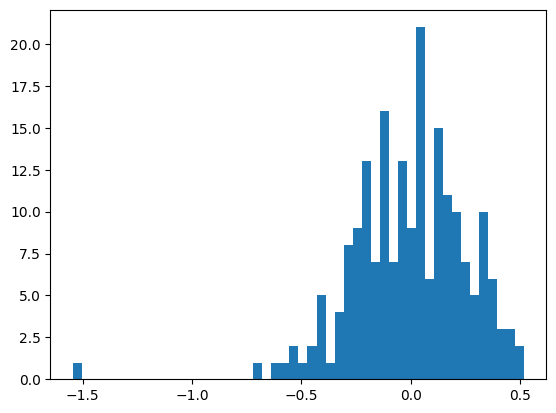

In [ ]:
plt.hist(h_pre_activation.mean(0, keepdim=True).view(-1).tolist(), bins=50)

(array([ 1.,  1.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  2.,  2.,  3.,
         3.,  4., 12., 13., 10., 22., 20., 23., 20., 15., 14.,  7., 10.,
         5.,  1.,  3.,  1.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.23822977, 0.29026442, 0.34229907, 0.39433372, 0.44636836,
        0.49840301, 0.55043766, 0.60247231, 0.65450696, 0.70654161,
        0.75857626, 0.81061091, 0.86264556, 0.91468021, 0.96671486,
        1.01874951, 1.07078416, 1.12281881, 1.17485346, 1.22688811,
        1.27892276, 1.33095741, 1.38299206, 1.43502671, 1.48706136,
        1.53909601, 1.59113065, 1.6431653 , 1.69519995, 1.7472346 ,
        1.79926925, 1.8513039 , 1.90333855, 1.9553732 , 2.00740785,
        2.0594425 , 2.11147715, 2.1635118 , 2.21554645, 2.2675811 ,
        2.31961575, 2.3716504 , 2.42368505, 2.4757197 , 2.52775435,
        2.579789  , 2.63182365, 2.6838583 , 2.73589294, 2.78792759,
        2.83996224]),
 <BarContainer

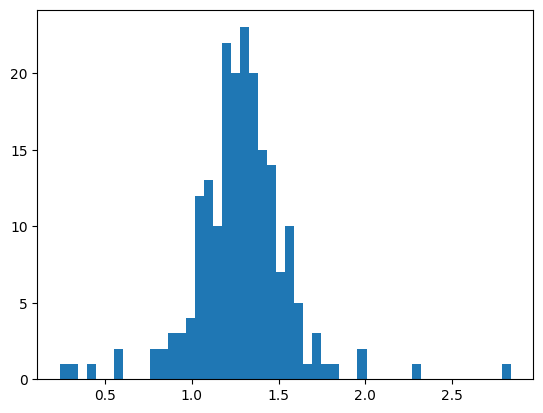

In [ ]:
plt.hist(h_pre_activation.std(0, keepdim=True).view(-1).tolist(), bins=50)